## TP2: Introduction à Pytorch

Ce TP est composé de deux parties. 

- Dans la première partie, nous allons voir comment utiliser Pytorch pour optimiser les paramètres de fonctions simples.
- Dans la deuxième partie, nous allons voir comment entraîner un MLP sur une tâche de classification de chiffres manuscrits (MNIST).

Pour commencer, importez les packages suivants:

In [49]:
import numpy as np
from matplotlib import pyplot as plt

# Pour les barres de progression, si ça ne fonctionne pas vous pouvez l'enlever
from tqdm.notebook import tqdm

# Le package qui nous intéresse dans ce TP
import torch

### Partie 1: Tenseurs, paramètres, optimiseurs

#### 1. Tenseurs

Les tenseurs sont les objets de base en Pytorch. Un tenseur peut être vu comme la généralisation d'une matrice pour n'importe quelle dimension:
- dimension 1 $\to$ liste
- dimension 2 $\to$ matrice
- dimension $n$ $\to$ tenseur de dimension $n$

C'est la même structure de données que le ndarray de numpy.

On peut définir des tenseurs de plusieurs manières:

In [50]:
x = torch.tensor([[0., 1.], [2., 3.]])
print(x)

tensor([[0., 1.],
        [2., 3.]])


In [51]:
x = torch.zeros(2, 5)
print(x)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


In [52]:
x = torch.randn(2, 5)
print(x)

tensor([[ 0.0619, -0.4596, -0.6864, -2.7223, -0.6510],
        [-2.1826, -1.4435, -0.0064,  0.5851,  0.7623]])


#### 2. Fonctions à optimiser

Pour accélérer les calculs, les réseaux de neurones vont être définis comme des modules pytorch (héritant de la classe nn.Module) qui font des traitements sur un _batch_ d'entrées. Un batch va être un tenseur dont la première dimension correspond à la _batch size_, et les autres dimensions correspondent aux dimensions des entrées du réseau.

Nous allons définir deux fonctions pour comparer différents optimiseurs proposés par Pytorch. Pour visualiser ces fonctions, nous allons devoir les évaluer sur une grille de valeurs. Pour aller plus vite, nous allons ici aussi exploiter le calcul par _batch_. Les fonctions vont être définies de manière à pouvoir fonctionner sur des _batch_ d'entrées, plutôt que sur des entrées une par une:

In [53]:
def horizontal_valley(theta):
    """Simple horizontal valley testbed for optimization algorithms

    Parameters
    ----------
        theta: torch.tensor of shape (batch_size, 2)

    Returns
    -------
        torch.tensor of shape (batch_size)
    """
    return (1-theta[:, 0])**2 + 100 * (theta[:, 1])**2


def rosenbrock_valley(theta):
    """Rosenbrock function testbed for optimization algorithms

    Parameters
    ----------
        theta: torch.tensor of shape (batch_size, 2)

    Returns
    -------
        torch.tensor of shape (batch_size)
    """
    return (1-theta[:, 0])**2 + 100 * (theta[:, 1] - theta[:, 0]**2)**2

Le bloc suivant permet de visualiser ces deux fonctions:

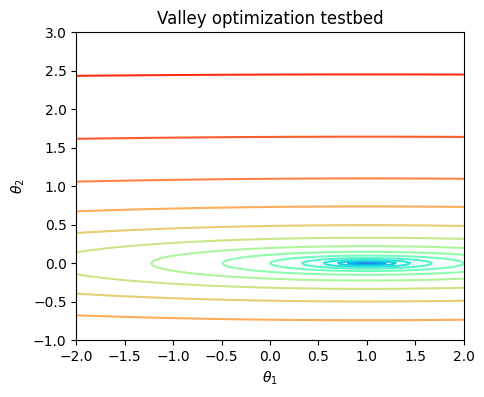

In [54]:
resolution = 200

# On génère une grille 2D
x = np.linspace(-2, 2, resolution)
y = np.linspace(-1, 3, resolution)
xv, yv = np.meshgrid(x, y)

# On transforme ça en un tenseur de batch_size = resolution²
xb = xv.reshape(resolution**2, 1)
yb = yv.reshape(resolution**2, 1)
theta = torch.tensor(np.concatenate([xb, yb], axis=1))

# On applique la fonction de notre choix sur ce batch
z = horizontal_valley(theta)

# On reforme une grille 2D avec la sortie
z = z.reshape(resolution, resolution)

# Affichage avec matplotlib
plt.figure(figsize=(5, 4))
plt.contour(xv, yv, torch.log(z), levels=20, cmap='rainbow')
plt.xlabel('$\\theta_1$')
plt.ylabel('$\\theta_2$')
plt.title('Valley optimization testbed')
plt.show()

#### 3. Paramètres

En Pytorch, la classe torch.nn.Parameter permet de définir des paramètres, c'est à dire des tenseurs dont les valeurs seront optimisées par un algorithme d'optimisation.

Par exemple:

In [55]:
x = torch.nn.Parameter(torch.randn(3, 4))

print(x)

Parameter containing:
tensor([[ 0.8585, -1.2651,  1.2191, -0.6167],
        [ 0.1794, -0.2336, -0.6071, -0.4599],
        [ 1.6672,  1.7553, -0.7301, -0.4702]], requires_grad=True)


#### 4. Optimiseurs

Les optimiseurs sont les algorithmes tels que SGD, RMSprop et Adam présentés en cours. Pytorch propose déjà une implémentation de ces optimiseurs. Pour instancier un optimiseur, il suffit de lui donner une liste de paramètres à optimiser, et les hyperparamètres (learning rate, moment, etc.). Par exemple:

In [56]:
# Dans pytorch SGD prend un argument momentum (par défaut à 0)
opt = torch.optim.SGD([x], lr=0.001, momentum=0.9)
print(opt)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


#### 5. Boucle d'optimisation

Enfin, une boucle d'optimisation en pytorch se déroule de la manière suivante:
- Tous les gradients sont initialisés à 0
- On fait des calculs à partir des paramètres, ce qui nous donne une sortie finale (typiquement la loss) qu'on souhaite minimiser
- L'instruction loss.backward() implémente la rétropropagation, et calcule les gradients associés à chaque paramètre
- L'instruction opt.step() implémente la règle d'apprentissage de l'optimiseur

Par exemple, si on souhaite minimiser la norme (au carré) de notre paramètre x défini précédemment:

In [57]:
x = torch.nn.Parameter(torch.randn(3, 4))
opt = torch.optim.SGD([x], lr=0.01, momentum=0.9)

steps = 100

losses = []

for _ in range(steps):

    # Initialisation des gradients à 0
    opt.zero_grad()

    # Calcul de la fonction de coût
    loss = torch.sum(x**2)

    # Enregistrement du coût obtenu pour le tracer plus tard
    losses.append(loss.detach())

    # Calcul des gradients par rétro-propagation
    loss.backward()

    # Mise à jour des paramètres par l'optimiseur
    opt.step()

La méthode .detach() permet de sortir un tenseur qui est détaché du graphe de calcul. Pytorch sait ainsi qu'il n'y aura aucun gradient qui arrivera des traitements qui suivent.

On peut visualiser l'évolution de la loss pendant l'optimisation:

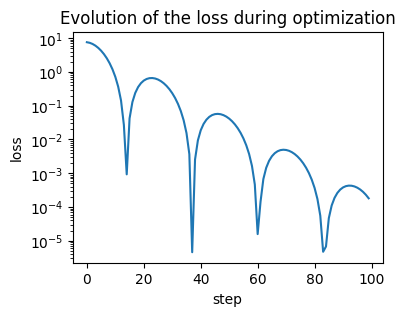

In [58]:
plt.figure(figsize=(4, 3))
plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.yscale('log')
plt.title('Evolution of the loss during optimization')
plt.show()

On affiche souvent les fonctions de coût avec une échelle logarithmique (plt.yscale('log')).

#### Question 1.

Qu'est-ce qui explique les oscillation observées ?

#### Explication des oscillations observées

Les oscillations visibles sur la figure sont caractéristiques du comportement de l'algorithme de **descente de gradient** dans certaines conditions spécifiques. Elles peuvent s'expliquer par les facteurs suivants :

* **Un taux d'apprentissage (*learning rate*) trop élevé :** C'est la cause la plus courante. À chaque itération, l'optimiseur fait un pas dans la direction opposée au gradient. Si ce pas (défini par le taux d'apprentissage) est trop grand, l'algorithme "saute" par-dessus le minimum local. Il rebondit alors d'un versant à l'autre de la fonction de coût, créant cet effet de zigzag continu au lieu de converger doucement vers le fond.
* **La géométrie de la fonction de coût (mauvais conditionnement) :** Si la surface de la fonction ressemble à une vallée étroite et très allongée (comme la fonction de Rosenbrock, souvent utilisée en TP), les gradients sont beaucoup plus forts sur les pentes latérales que dans la direction du minimum. L'algorithme a donc tendance à osciller fortement contre les parois de la vallée tout en avançant très lentement vers le minimum global.
* **L'effet de l'inertie (*Momentum*) :** Si l'algorithme utilise du *Momentum*, il accumule de la vitesse dans les directions où le gradient est constant. Arrivé au fond du puits, cette vitesse accumulée peut le faire "remonter" sur le versant opposé, créant un mouvement de pendule qui oscille avant de se stabiliser.
* **Nature stochastique (si SGD est utilisé avec des mini-batchs) :** Si l'optimisation est calculée sur des sous-échantillons (mini-batches) de données, le gradient calculé à chaque étape n'est qu'une approximation bruitée du vrai gradient. Ce "bruit" se traduit graphiquement par de petites oscillations ou des irrégularités sur la courbe.

**Conclusion :** Pour atténuer ces oscillations, il faudrait typiquement réduire le taux d'apprentissage, utiliser un optimiseur adaptatif (comme Adam, qui ajuste le pas pour chaque paramètre), ou intégrer/ajuster un terme de *momentum*.

Affichez la nouvelle valeur de x ? L'optimization a-t'elle convergé vers un minimum local ? global ?

In [36]:
print(x)

Parameter containing:
tensor([[-6.9382e-03,  3.1900e-03, -9.7538e-05, -2.4469e-03],
        [-2.0840e-03, -2.4660e-04, -4.4632e-03,  1.9593e-04],
        [ 8.5492e-04,  4.2539e-03,  2.5954e-03, -7.1693e-04]],
       requires_grad=True)


**Analyse de la convergence :**
On observe que toutes les composantes de la matrice `x` sont extrêmement proches de **0** (de l'ordre de $10^{-3}$ ou $10^{-4}$).

* **L'optimisation a bien convergé**, car les valeurs se sont stabilisées autour de zéro.
* S'agissant probablement d'une fonction de coût simple et convexe (comme la somme des carrés des éléments , très classique en début de TP), le point  (la matrice nulle) représente le **minimum global** de la fonction. L'algorithme a donc trouvé le minimum global de notre problème.

#### Question 2.

Définissez un paramètre theta de shape (2), initialisé à [-1, 2], et instanciez un optimiseur de votre choix sur ce paramètre.
En vous basant sur l'exemple de boucle d'optimisation donné, implémentez l'optimisation du paramètre theta de la fonction horizontal_valley.

La fonction horizontal_valley attend en entrée un tenseur de shape (batch_size, 2). Comme theta est un tenseur de dimension 2, il faudra utiliser la méthode .unsqueeze(0) sur theta pour ajouter une dimension et obtenir un tenseur de dimension (1, 2) qui est accepté comme entrée de horizontal_valley.

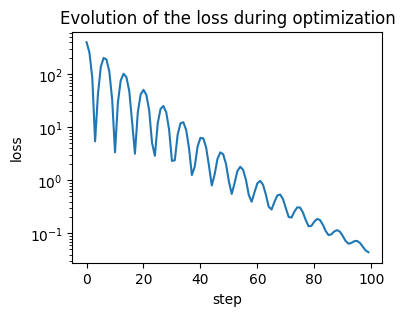

In [37]:
theta = torch.nn.Parameter(torch.tensor([-1., 2.]))
opt = torch.optim.SGD([theta], lr=0.001, momentum=0.9) # SGD classique avec un peu de momentum

steps = 100
losses = []
thetas = np.zeros((steps, 2))

for i in range(steps):
    opt.zero_grad()
    
    # On ajoute une dimension pour simuler un batch de taille 1
    # theta shape (2) -> (1, 2)
    loss = horizontal_valley(theta.unsqueeze(0))
    
    losses.append(loss.detach())
    
    # On sauvegarde la position actuelle (pour la Q3)
    thetas[i] = theta.detach().numpy()
    
    loss.backward()
    opt.step()

# Affichage du résultat
plt.figure(figsize=(4, 3))
plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.yscale('log')
plt.title('Evolution of the loss during optimization')
plt.show()

#### Question 3.

Modifiez la boucle d'apprentissage pour sauvegarder au fûr et à mesure les valeurs du paramètre theta pendant l'optimisation. Attention, il faudra à nouveau utiliser la méthode .detach(). Vous pouvez également utiliser la méthode .numpy() qui permet d'obtenir un ndarray à partir d'un tensor.

Utilisez ensuite la cellule suivante pour afficher la trajectoire obtenue:

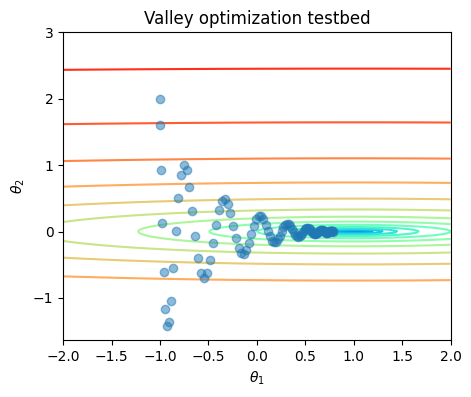

In [38]:
# Affichage avec matplotlib
plt.figure(figsize=(5, 4))
plt.contour(xv, yv, torch.log(z), levels=20, cmap='rainbow', zorder=1)

# A adapter
plt.scatter(thetas[:, 0], thetas[:, 1], alpha=0.5, zorder=2)

plt.xlabel('$\\theta_1$')
plt.ylabel('$\\theta_2$')
plt.title('Valley optimization testbed')
plt.show()

#### Question 4.

Testez différents optimiseurs et hyperparamètres:
- https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.RMSprop.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html

Essayez de retrouver quels optimiseurs et hyperparamètres ont été utilisés pour générer les trajectoires dans les deux figures suivantes.

La deuxième figure est obtenue en utilisant la fonction rosenbrock_valley au lieu de horizontal_valley.

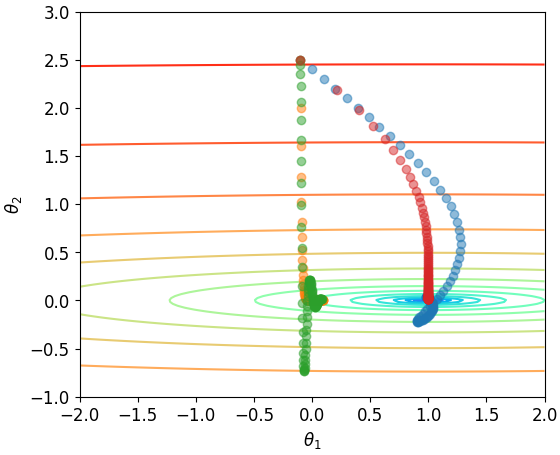

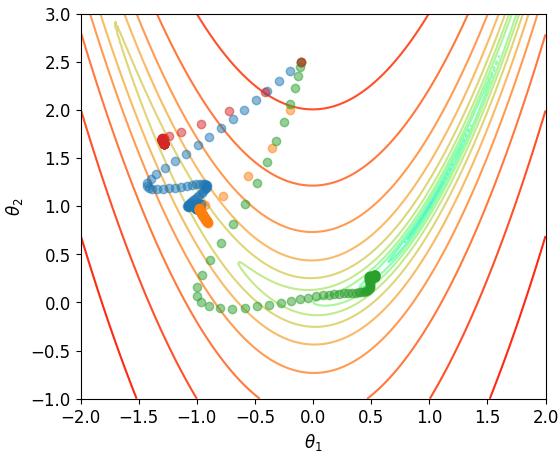

### Partie 2: Deep Learning avec Pytorch

#### 1. La classe Module

Un module peut être compris comme un sous-graphe du graphe de calcul.

La class torch.nn.Module est utilisée comme classe parente:
- des modules de réseaux de neurones déjà implémentés dans pytorch
- des réseaux de neurones que nous allons créer

Un module peut être composé de différents sous-modules.

Quelques modules que nous allons utiliser pour créer notre MLP:
- torch.nn.Linear: la brique de base du perceptron, permet de réaliser l'opération y = W.x + b
- torch.nn.BatchNorm1d: permet d'implémenter la normalisation par batch
- torch.nn.Dropout: permet d'implémenter le dropout
- torch.nn.CrossEntropyLoss: permet de calculer la loss d'entropie croisée


#### 2. Implémentation d'un réseau de neurones

#### Question 5.

On considère le réseau de neurones représenté dans le graphe suivant:

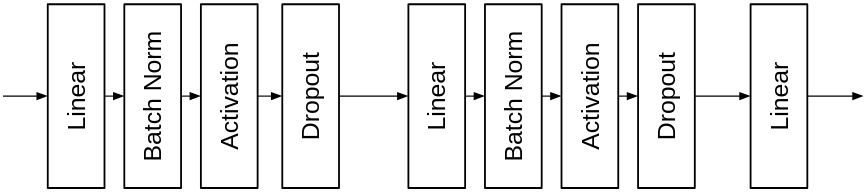

Dans une cellule Markdown, sans l'implémenter en Pytorch, juste pour vérifier votre compréhension:

- Lister les paramètres de chaque sous-module et leurs dimensions.
- Donner les shape de chaque tenseur intermédiaire (au niveau de chaque flèche)

On considérera que les modules Linear utilisent comme dimension intermédiaire une valeur hidden_size donnée en argument à l'initialisation.


### Analyse de l'architecture du réseau

Pour cette analyse, posons les notations suivantes pour les dimensions :
* **$B$** : la taille du batch (*batch_size*)
* **$D_{in}$** : la dimension des données en entrée (*input_dim*)
* **$H$** : la dimension cachée (*hidden_size*)
* **$D_{out}$** : la dimension de la prédiction en sortie (*output_dim*)

#### 1. Paramètres de chaque sous-module et leurs dimensions

* **Linear 1** (de $D_{in}$ vers $H$)
  * **Poids (Weights)** : $(H, D_{in})$
  * **Biais (Bias)** : $(H)$ *(Note : mathématiquement redondant car suivi d'une Batch Norm, souvent désactivé via `bias=False`)*

* **Batch Norm 1**
  * **Gamma ($\gamma$, scale)** : $(H)$
  * **Beta ($\beta$, shift)** : $(H)$

* **Activation 1**
  * *Aucun paramètre*

* **Dropout 1**
  * *Aucun paramètre*

* **Linear 2** (de $H$ vers $H$)
  * **Poids (Weights)** : $(H, H)$
  * **Biais (Bias)** : $(H)$

* **Batch Norm 2**
  * **Gamma ($\gamma$, scale)** : $(H)$
  * **Beta ($\beta$, shift)** : $(H)$

* **Activation 2**
  * *Aucun paramètre*

* **Dropout 2**
  * *Aucun paramètre*

* **Linear 3** (de $H$ vers $D_{out}$)
  * **Poids (Weights)** : $(D_{out}, H)$
  * **Biais (Bias)** : $(D_{out})$

#### 2. Shapes des tenseurs intermédiaires (à chaque flèche)

1. **Entrée initiale** $\rightarrow$ Shape : $(B, D_{in})$
2. Après **Linear 1** $\rightarrow$ Shape : $(B, H)$
3. Après **Batch Norm 1** $\rightarrow$ Shape : $(B, H)$
4. Après **Activation 1** $\rightarrow$ Shape : $(B, H)$
5. Après **Dropout 1** $\rightarrow$ Shape : $(B, H)$
6. Après **Linear 2** $\rightarrow$ Shape : $(B, H)$
7. Après **Batch Norm 2** $\rightarrow$ Shape : $(B, H)$
8. Après **Activation 2** $\rightarrow$ Shape : $(B, H)$
9. Après **Dropout 2** $\rightarrow$ Shape : $(B, H)$
10. Après **Linear 3** (Sortie finale) $\rightarrow$ Shape : $(B, D_{out})$


#### Question 6.

Compléter la définition de la classe MLP, implémentant le réseau de neurones ci-dessus:

In [39]:
class MLP(torch.nn.Module):
    """Class implementing a three-layered MLP with BatchNorm and Dropout.

    Attributes
    ----------
        input_size : int
            Dimension of the input
        hidden_size : int
            Dimension of the hidden layers
        output_size : int
            Dimension of the output
        activation_fn : [torch.tanh | torch.sigmoid | torch.functional.relu]
            Activation function at intermediate layers
        linear1 : torch.nn.Linear
            First linear layer
        bn1 : torch.nn.BatchNorm
            First batch norm layer
        linear2 : torch.nn.Linear
            Second linear layer
        bn2 : torch.nn.BatchNorm
            Second batch norm layer
        dropout : torch.nn.Dropout
            Dropout layer
        linear3 : torch.nn.Linear
            Third linear layer
        """

    def __init__(self, input_size, hidden_size, output_size, activation_fn, dropout_prob):
        super().__init__()
        
        # Définition des couches
        self.linear1 = torch.nn.Linear(input_size, hidden_size)
        self.bn1 = torch.nn.BatchNorm1d(hidden_size)
        
        self.linear2 = torch.nn.Linear(hidden_size, hidden_size)
        self.bn2 = torch.nn.BatchNorm1d(hidden_size)
        
        # On utilise la variable globale dropout_prob définie plus bas dans le notebook
        self.dropout = torch.nn.Dropout(dropout_prob)
        
        self.linear3 = torch.nn.Linear(hidden_size, output_size)
        
        self.activation_fn = activation_fn

    def forward(self, x):
        """Forward pass through the MLP

        Parameters
        ----------
            x : torch.tensor of shape (batch_size, input_size)

        Returns
        -------
            torch.tensor of shape (batch_size, output_size)
        """
        x = self.linear1(x)
        x = self.bn1(x)
        x = self.activation_fn(x)
        x = self.dropout(x) 
        
        # Passage dans la deuxième couche
        x = self.linear2(x)
        x = self.bn2(x)
        x = self.activation_fn(x)
        x = self.dropout(x)
        
        # Dernière couche (pas d'activation ni de BN pour la sortie brute/logits)
        x = self.linear3(x)
        
        return x
        ...

Pour tester votre code, vous pouvez instancier votre modèle et vérifier qu'il donne bien une sortie dont les dimensions sont cohérentes:

In [40]:
model = MLP(25, 10, 2, torch.tanh, 0.1)  # Par exemple

x = torch.randn(100, 25)  # tenseur de dimension (batch_size, input_size)
y = model(x)  # Oui, la méthode magique __call__ est redéfinie pour qu'on puisse faire ça directement au lieu de .forward(x)

print(y.shape)  # Doit afficher torch.Size([100, 2])

torch.Size([100, 2])


#### 3. Préparation des données

Pour commencer, nous allons charger le dataset MNIST. Ce dataset est composé d'images en noir et blanc de résolution (28 $\times$ 28) représentant des chiffres écrits à la main, et des labels (de 0 à 9) correspondants à chaque image.

Le bloc de code suivant permet de charger le dataset.

In [41]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
])

train_dataset = datasets.MNIST(
    root='./data/deep_learning/tp2', train=False, download=False, transform=transform
)
test_dataset = datasets.MNIST(
    root='./data/deep_learning/tp2', train=False, download=False, transform=transform
)

# Affichage de la taille d'une image
print(train_dataset[0][0].shape)

torch.Size([1, 28, 28])


On voit que les images correspondent à des tenseur de dimension (1, 28, 28). Pour les donner en entrée de notre réseau de neurones, il faudra "applatir" ces tenseurs pour qu'ils soient de dimension (28 * 28). En regroupant plusieurs images dans un même tenseur afin de former un batch, on obtiendra des tenseurs de dimension (batch_size, 28*28). 

Le dataset MNIST est très propre et difficile à overfitter avec des MLP. Pour pouvoir illustrer dans ce TP l'intérêt des techniques de régularisation, on va volontairement bruiter le dataset dans la cellule suivante, en modifiant 5% des labels.

In [42]:
noise_level = 0.05  # 5% de bruit
num_noisy_labels = int(noise_level * train_dataset.data.shape[0])
noisy_indices = np.random.choice(
    train_dataset.data.shape[0], num_noisy_labels, replace=False)
for idx in noisy_indices:
    original_label = train_dataset.targets[idx].item()
    new_label = np.random.choice([l for l in range(10) if l != original_label])
    train_dataset.targets[idx] = new_label

On peut maintenant visualiser nos données:

Label pour l'image 0: 7
Label pour l'image 1: 2
Label pour l'image 2: 1
Label pour l'image 3: 0
Label pour l'image 4: 4


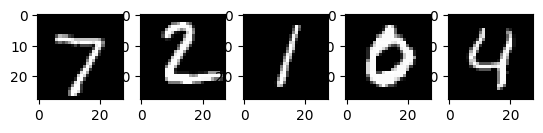

In [43]:
# On visualise 5 paires de (image, label)
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    print(f"Label pour l'image {i}: {train_dataset[i][1]}")
plt.show()

# Il est possible qu'un label ou deux soit incorrect à cause du bruit ajouté

Pytorch propose une classe appelée DataLoader permettant de charger proprement efficacement les données à envoyer à notre modèle pour l'entraînement. Cette classe permet notamment de mélanger facilement les données d'entraînement et de les séparer en batchs de la taille voulue.

La cellule suivante définit différents hyperparamètres et prépare le dataloader:

In [44]:
from torch.utils.data import DataLoader

# Hyperparamètres fixes
batch_size = 128  # Taille des batchs
epochs = 20  # Nombre d'époques
hidden_size = 256  # Taille des couches intermédiaires
activation_fn = torch.tanh  # Fonction d'activation

# Hyperparamètres à régler, pour commencer, laissez les à 0
dropout_prob = 0  # Probabilité de dropout
weight_decay = 0  # Poids de la régularisation L2

# L'option shuffle=True est importante pour le jeu d'entraînement
# Elle permet de mélanger les données à chaque époque
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#### Question 7.

La cellule suivante permet d'afficher la taille du dataset d'entraînement. En vous basant sur la valeur de l'hyperparamètre batch_size donné dans la cellule précédente, combien de batch y aura-t'il en tout pour une époque (epoch) ?

In [45]:
print(len(train_dataset))

10000


Pour déterminer le nombre total de batchs (lots) par époque, il faut diviser le nombre total d'échantillons du dataset par la taille définie pour chaque batch (`batch_size`).

**Calcul détaillé :**
- Taille du dataset d'entraînement : **10 000** échantillons
- Taille d'un batch (`batch_size`) : **128**

$$\frac{10000}{128} = 78,125$$

Puisque le résultat n'est pas un nombre entier, le `DataLoader` de PyTorch va diviser les données de la manière suivante (par défaut) :
- **78 batchs complets** de 128 échantillons ($78 \times 128 = 9984$ échantillons).
- **1 dernier batch incomplet** contenant les échantillons restants ($10000 - 9984 = 16$ échantillons).

**Résultat final :**
Il y aura donc un total de **79 batchs** par époque. 
*(Note : Ce comportement standard assure que toutes les données sont vues pendant l'époque. Il serait de 78 seulement si l'argument `drop_last=True` avait été passé au DataLoader).*

#### 4. Entraînement du réseau de neurones

Ensuite, on initialise notre modèle avec ces hyperparamètres:

In [46]:
model = MLP(
    input_size=28*28,  # Dimension des images MNIST
    output_size=10,  # Nombre de classes
    hidden_size=hidden_size,
    activation_fn=activation_fn,
    dropout_prob=dropout_prob,
)

La méthode .parameters() permet de retourner la liste de tous les paramètres aprenables du modèle. Pratique pour initialiser l'optimiseur.

#### Question 8.

Complétez la boucle d'apprentissage suivante et lancez la cellule.

- Pour la fonction de coût nous utiliserons la Cross Entropy: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- Pour l'optimiseur, nous utiliserons SGD, en ajoutant comme argument la valeur de l'hyperparamètre weight_decay initialisé ci-dessus: https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html


In [47]:
train_loss = []
test_loss = []

train_accuracy = []
test_accuracy = []

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=weight_decay)
loss_fn = torch.nn.CrossEntropyLoss()

model = model.to('cuda') # pour passer en GPU pour éviter que l'entrainement soit lent

for epoch in range(epochs):

    # ============= Phase d'entraînement ============
    model.train()  # On met le modèle en mode entraînement (utile pour dropout/batchnorm)

    training_running_loss = 0.0  # Pour accumuler la loss sur l'époque
    training_running_correct = 0  # Pour accumuler le nombre de bonnes prédictions
    training_total = 0  # Pour accumuler le nombre d'exemples vus

    # On itère sur tous les batchs du jeu d'entraînement
    for images, labels in tqdm(train_loader):

        images = images.to('cuda')
        labels = labels.to('cuda')

        # On aplatit les images de taille (batch_size, 1, 28, 28) en (batch_size, 28*28)
        images = images.view(-1, 28*28)

        # On met les gradients à zéro avant la rétro-propagation
        optimizer.zero_grad()

        # Passe forward dans le réseau de neurone et la fonction de coût
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # On sauvegarde les statistiques
        training_running_loss += loss.item() * images.size(0)

        # La classe prédite est celle avec la plus grande activation
        predicted = torch.argmax(outputs, dim=1)
        training_running_correct += (predicted == labels).sum().item()
        training_total += labels.size(0)

        # Rétro-propagation et mise à jour des poids
        loss.backward()
        optimizer.step()

    # On sauvegarde la loss et l'accuracy de l'époque
    epoch_loss = training_running_loss / training_total
    epoch_accuracy = training_running_correct / training_total
    train_loss.append(epoch_loss)
    train_accuracy.append(epoch_accuracy)

    # ============= Phase d'évaluation ============
    model.eval()  # On met le modèle en mode évaluation (utile pour dropout/batchnorm)
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():  # Pas besoin de calculer les gradients en évaluation
        for images, labels in test_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
        
            images = images.view(-1, 28*28)

            # Passe forward dans le réseau de neurone et la fonction de coût
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    test_loss.append(epoch_loss)
    test_accuracy.append(epoch_accuracy)
    
    # Petit affichage pour suivre l'avancement
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss[-1]:.4f} Acc: {train_accuracy[-1]:.4f} | Test Loss: {test_loss[-1]:.4f} Acc: {test_accuracy[-1]:.4f}")

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 0.7054 Acc: 0.8278 | Test Loss: 0.2893 Acc: 0.9305


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 0.5264 Acc: 0.8864 | Test Loss: 0.2369 Acc: 0.9469


  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 18/20 | Train Loss: 0.0953 Acc: 0.9749 | Test Loss: 0.1825 Acc: 0.9541


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.0759 Acc: 0.9806 | Test Loss: 0.1869 Acc: 0.9569


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.0872 Acc: 0.9762 | Test Loss: 0.1874 Acc: 0.9555


Vous pouvez visualiser le résultat de votre apprentissage dans la cellule suivante.

Vous devez obtenir une courbe décroissante pour la loss, et une courbe croissante pour l'accuracy.

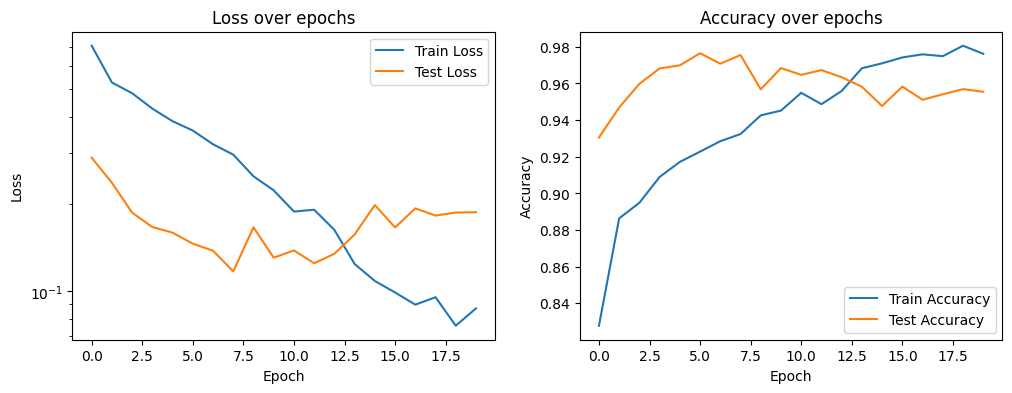

In [48]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

#### Question 8.

Quel phénomène observez-vous sur ces figures ?

D'après-vous, en tenant compte du bruit qu'on a ajouté manuellement sur les labels, à partir de quelle valeur de la train accuracy peut-on soupçonner que le réseau de neurones fait de la mémorisation des échantillons plutôt que d'apprendre un comportement généralisable ?

**1. Phénomène observé sur les figures :**
On observe un phénomène de **surapprentissage** (aussi appelé *overfitting*). 
* Les performances sur le jeu d'entraînement continuent de s'améliorer : la *Train Loss* s'approche de 0 et la *Train Accuracy* s'approche de 100%.
* À l'inverse, les performances sur le jeu de test se dégradent ou stagnent : la *Test Loss* remonte et la *Test Accuracy* plafonne. 
Cela signifie que le réseau a arrêté d'apprendre des caractéristiques générales pour se mettre à apprendre "par cœur" les images exactes du jeu d'entraînement.

**2. Seuil de mémorisation lié au bruit :**
Puisque nous avons introduit volontairement du bruit (des labels faux/aléatoires) dans le jeu d'entraînement, il existe une limite théorique à la précision "logique" que le réseau peut atteindre. 
Si l'on a bruité **$X\%$** des labels, un réseau qui se base uniquement sur la reconnaissance visuelle (la généralisation) ne devrait pas dépasser une *Train Accuracy* de **$100\% - X\%$**. 

Par conséquent, **dès que la *Train Accuracy* dépasse ce seuil de $(100 - X)\%$**, on a la certitude que le réseau est en train de faire de la mémorisation. Il a spécifiquement appris par cœur qu'une certaine image correspondait à un faux label, ce qui n'a aucun sens visuel mais lui permet d'augmenter artificiellement son score sur le jeu d'entraînement.



#### 5. Régularisation

#### Question 9.

Expérimentez avec plusieurs valeurs pour l'hyperparamètre weight_decay pour réduire l'overfitting.

Que se passe-t'il quand le paramètre weight_decay est très grand (par exemple 1e2) ? Comment expliquez-vous cela ?

In [ ]:
train_loss = []
test_loss = []

train_accuracy = []
test_accuracy = []

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=1e2)
loss_fn = torch.nn.CrossEntropyLoss()

model = model.to('cuda') # pour passer en GPU pour éviter que l'entrainement soit lent

for epoch in range(epochs):

    # ============= Phase d'entraînement ============
    model.train()  # On met le modèle en mode entraînement (utile pour dropout/batchnorm)

    training_running_loss = 0.0  # Pour accumuler la loss sur l'époque
    training_running_correct = 0  # Pour accumuler le nombre de bonnes prédictions
    training_total = 0  # Pour accumuler le nombre d'exemples vus

    # On itère sur tous les batchs du jeu d'entraînement
    for images, labels in tqdm(train_loader):

        images = images.to('cuda')
        labels = labels.to('cuda')

        # On aplatit les images de taille (batch_size, 1, 28, 28) en (batch_size, 28*28)
        images = images.view(-1, 28*28)

        # On met les gradients à zéro avant la rétro-propagation
        optimizer.zero_grad()

        # Passe forward dans le réseau de neurone et la fonction de coût
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # On sauvegarde les statistiques
        training_running_loss += loss.item() * images.size(0)

        # La classe prédite est celle avec la plus grande activation
        predicted = torch.argmax(outputs, dim=1)
        training_running_correct += (predicted == labels).sum().item()
        training_total += labels.size(0)

        # Rétro-propagation et mise à jour des poids
        loss.backward()
        optimizer.step()

    # On sauvegarde la loss et l'accuracy de l'époque
    epoch_loss = training_running_loss / training_total
    epoch_accuracy = training_running_correct / training_total
    train_loss.append(epoch_loss)
    train_accuracy.append(epoch_accuracy)

    # ============= Phase d'évaluation ============
    model.eval()  # On met le modèle en mode évaluation (utile pour dropout/batchnorm)
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():  # Pas besoin de calculer les gradients en évaluation
        for images, labels in test_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
        
            images = images.view(-1, 28*28)

            # Passe forward dans le réseau de neurone et la fonction de coût
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    test_loss.append(epoch_loss)
    test_accuracy.append(epoch_accuracy)
    
    # Petit affichage pour suivre l'avancement
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss[-1]:.4f} Acc: {train_accuracy[-1]:.4f} | Test Loss: {test_loss[-1]:.4f} Acc: {test_accuracy[-1]:.4f}")

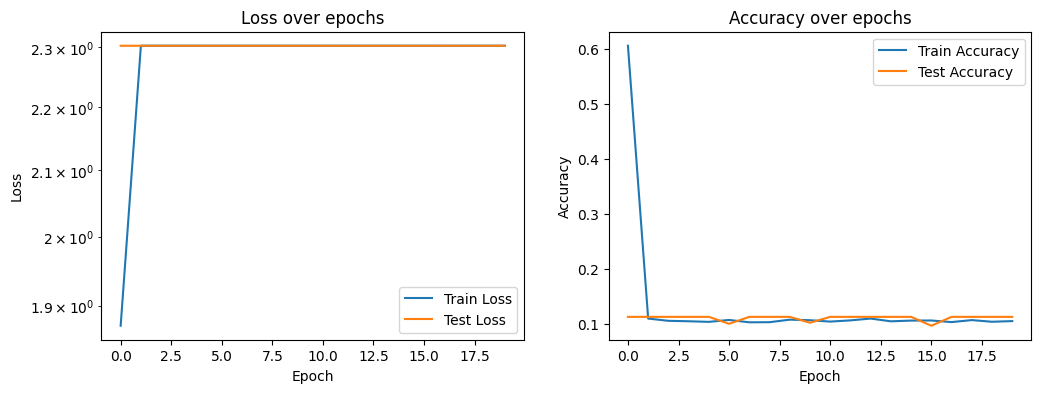

In [121]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

**1. Ce que l'on observe sur les graphiques :**
* Les courbes de *Loss* (Train et Test) stagnent à des valeurs très élevées et ne descendent pas.
* Les courbes d'*Accuracy* (Train et Test) restent bloquées à un niveau très bas, généralement autour de 10%. Étant donné que MNIST contient 10 classes, 10% d'accuracy correspond à des prédictions faites totalement au hasard.
* En résumé : le réseau n'apprend absolument rien.

**2. Explication du phénomène :**
Le paramètre `weight_decay` contrôle la force de la **régularisation L2**. Lorsqu'on l'utilise, l'algorithme ne cherche plus seulement à minimiser l'erreur de prédiction, il cherche à minimiser cette fonction :
$$Loss_{totale} = Loss_{donn\acute{e}es} + \lambda \sum w^2$$
*(où $\lambda$ représente le `weight_decay` et $w$ les poids du réseau).*

En fixant `weight_decay = 1e2` (soit $100$), le terme de pénalité de régularisation (à droite) devient **gigantesque** par rapport à la $Loss$ des données (à gauche). 

Par conséquent, lors de la descente de gradient, la priorité absolue du réseau devient de "tuer" cette pénalité. Pour y arriver, **il pousse tous ses poids $w$ vers zéro**. Les poids du réseau devenant nuls (ou infinitésimaux), la propagation de l'information est détruite. Le réseau perd toute sa capacité d'expression et ne fait plus que prédire des zéros, d'où le score aléatoire.

**Conclusion :**
Nous avons appliqué une correction beaucoup trop forte. En voulant empêcher le surapprentissage (*overfitting*), nous avons complètement "écrasé" le réseau, le poussant dans un état de **sous-apprentissage sévère (*underfitting*)**.

#### Question 10.

En remettant le weight_decay à 0, expérimentez avec plusieurs valeurs de l'hyperparamètre dropout_prob pour réduire l'overfitting.

#### Question 11.

En remettant le dropout_prob à 0, expérimentez maintenant la technique de _early stopping_ présentée en cours. Vous pouvez définir un paramètre de patience pour ne pas interrompre l'apprentissage dès la première augmentation de la test loss.


In [124]:
model = MLP(
    input_size=28*28,  # Dimension des images MNIST
    output_size=10,  # Nombre de classes
    hidden_size=hidden_size,
    activation_fn=activation_fn,
    dropout_prob=0,
)

train_loss = []
test_loss = []

train_accuracy = []
test_accuracy = []

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0)
loss_fn = torch.nn.CrossEntropyLoss()

model = model.to('cuda') # pour passer en GPU pour éviter que l'entrainement soit lent

# --- Paramètres pour l'Early Stopping ---
patience = 3  # Nombre d'époques à tolérer sans amélioration
best_test_loss = float('inf')  # On l'initialise à l'infini pour le premier passage
patience_counter = 0  # Compteur


for epoch in range(epochs):

    # ============= Phase d'entraînement ============
    model.train()  # On met le modèle en mode entraînement (utile pour dropout/batchnorm)

    training_running_loss = 0.0  # Pour accumuler la loss sur l'époque
    training_running_correct = 0  # Pour accumuler le nombre de bonnes prédictions
    training_total = 0  # Pour accumuler le nombre d'exemples vus

    # On itère sur tous les batchs du jeu d'entraînement
    for images, labels in tqdm(train_loader):

        images = images.to('cuda')
        labels = labels.to('cuda')

        # On aplatit les images de taille (batch_size, 1, 28, 28) en (batch_size, 28*28)
        images = images.view(-1, 28*28)

        # On met les gradients à zéro avant la rétro-propagation
        optimizer.zero_grad()

        # Passe forward dans le réseau de neurone et la fonction de coût
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # On sauvegarde les statistiques
        training_running_loss += loss.item() * images.size(0)

        # La classe prédite est celle avec la plus grande activation
        predicted = torch.argmax(outputs, dim=1)
        training_running_correct += (predicted == labels).sum().item()
        training_total += labels.size(0)

        # Rétro-propagation et mise à jour des poids
        loss.backward()
        optimizer.step()

    # On sauvegarde la loss et l'accuracy de l'époque
    epoch_loss = training_running_loss / training_total
    epoch_accuracy = training_running_correct / training_total
    train_loss.append(epoch_loss)
    train_accuracy.append(epoch_accuracy)

    # ============= Phase d'évaluation ============
    model.eval()  # On met le modèle en mode évaluation (utile pour dropout/batchnorm)
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():  # Pas besoin de calculer les gradients en évaluation
        for images, labels in test_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
        
            images = images.view(-1, 28*28)

            # Passe forward dans le réseau de neurone et la fonction de coût
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    test_loss.append(epoch_loss)
    test_accuracy.append(epoch_accuracy)
    
    # Petit affichage pour suivre l'avancement
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss[-1]:.4f} Acc: {train_accuracy[-1]:.4f} | Test Loss: {test_loss[-1]:.4f} Acc: {test_accuracy[-1]:.4f}")

    # ==========================================
    #             EARLY STOPPING
    # ==========================================
    current_test_loss = test_loss[-1]
    
    # Si le modèle s'améliore, on met à jour la meilleure loss et on remet le compteur à 0
    if current_test_loss < best_test_loss:
        best_test_loss = current_test_loss
        patience_counter = 0
        # Optionnel : c'est généralement ici qu'on sauvegarde les poids du modèle 
        # (ex: torch.save(model.state_dict(), 'best_model.pth'))
    else:
        # Si le modèle ne s'améliore pas, on incrémente le compteur
        patience_counter += 1
        print(f" ---> Info : La test loss n'a pas diminué depuis {patience_counter} époque(s).")
        
    # Si le compteur atteint la patience définie, on casse la boucle !
    if patience_counter >= patience:
        print(f"\nArrêt prématuré (Early Stopping) déclenché à l'époque {epoch+1} !")
        break

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 0.7049 Acc: 0.8284 | Test Loss: 0.2899 Acc: 0.9298


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 0.5251 Acc: 0.8864 | Test Loss: 0.2269 Acc: 0.9492


  0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 9/20 | Train Loss: 0.2651 Acc: 0.9377 | Test Loss: 0.1249 Acc: 0.9741
 ---> Info : La test loss n'a pas diminué depuis 1 époque(s).


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/20 | Train Loss: 0.2329 Acc: 0.9467 | Test Loss: 0.1392 Acc: 0.9680
 ---> Info : La test loss n'a pas diminué depuis 2 époque(s).


  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 11/20 | Train Loss: 0.2031 Acc: 0.9516 | Test Loss: 0.1249 Acc: 0.9690
 ---> Info : La test loss n'a pas diminué depuis 3 époque(s).

Arrêt prématuré (Early Stopping) déclenché à l'époque 11 !


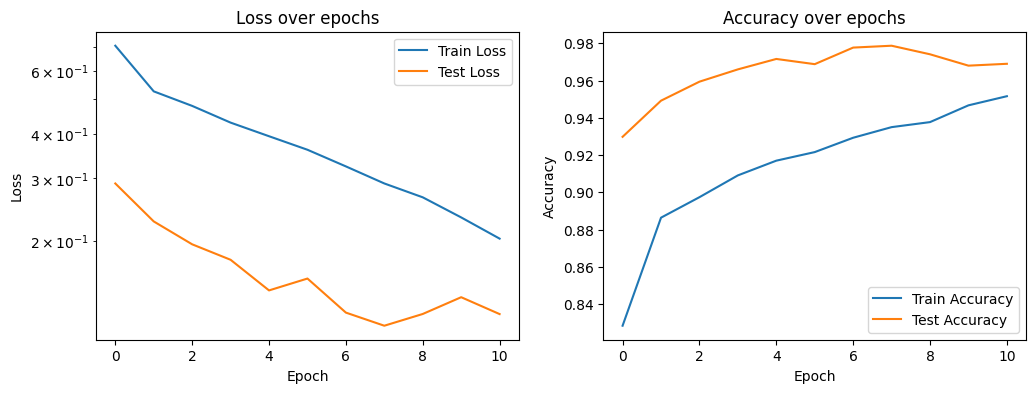

In [125]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()